In [20]:
import uproot
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
file = "/home/dsalma/damicm-ml/img_8_samples/panaSKImg_clustersRec_cut_9_ext1.root"

In [22]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'info;1', 'process_config;1']


In [23]:
clustersRec_tree = f["clustersRec"]

In [24]:
df = clustersRec_tree.arrays(library="pd")

In [25]:
try:
    import awkward as ak
except Exception:
    ak = None

def to_list_maybe(x):
    # Handle common array-likes
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return list(x)
    # Awkward arrays
    if ak is not None:
        try:
            return ak.to_list(x)
        except Exception:
            pass
    # Some awkward objects have .to_list()
    if hasattr(x, "to_list"):
        try:
            return x.to_list()
        except Exception:
            pass
    # Not an array -> return None so we can repeat later
    return None

# --- Choose columns (drop the blockers) ---
cols = [c for c in df.columns if c not in ["RUNID", "Nclusters"]]

# Use the first row (you said there's 1 row)
row = df.iloc[0]

# Find target length (e.g., 991) from the first array-like column
N = None
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is not None:
        N = len(seq)
        break
if N is None:
    raise ValueError("Couldn't find any array-like columns to expand.")

# Build dict of columns -> sequences (repeat scalars)
data = {}
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is None:
        # scalar: repeat it N times
        data[c] = [row[c]] * N
    else:
        data[c] = seq

df_expanded = pd.DataFrame(data).reset_index(drop=True)

print(df_expanded.shape)  
df_expanded.head()

(58, 56)


,DX,DY,Energy,Energy_AVG,Energy_PS,Npix,PosX,PosY,Qmax,QmaxX,...,readout_end,readout_start,seed_nsig_delta,seed_nsig_max,seed_nsig_min,seed_nsig_pixels,sigma_seed_eV,wSTD_X,wSTD_XY,wSTD_Y
0,1.0,1.0,2.788828,9.491022e+02,9.917490e+02,1,7.000000,1.000000,2.788828,7.0,...,1.758643e+09,1.758613e+09,0.000000,1909.961670,1909.961670,[1909.961669921875],1.460149,0.000000,0.000000,0.000000
1,2.0,1.0,4.834251,1.633839e+03,1.719132e+03,2,19.734768,1.000000,3.552051,20.0,...,1.758643e+09,1.758613e+09,1554.534302,2432.664307,878.130005,"[878.1300048828125, 2432.664306640625]",1.460149,0.441457,0.312157,0.000000
2,68.0,131.0,2713.030762,8.853448e+05,9.647943e+05,1861,69.113297,60.245872,14.056318,65.0,...,1.758643e+09,1.758613e+09,9616.564453,9626.635742,10.071788,"[20.43376350402832, 227.24432373046875, 1071.1...",1.460149,13.798297,22.751741,29.066999
3,7.0,7.0,27.808876,8.353508e+03,9.889253e+03,36,141.881897,3.417408,2.354322,142.0,...,1.758643e+09,1.758613e+09,1600.105347,1612.385376,12.279931,"[136.4253692626953, 629.7105102539062, 1245.84...",1.460149,1.033118,1.360996,1.623973
4,161.0,150.0,8360.041016,2.762046e+06,2.972956e+06,4929,155.139084,100.558640,20.093657,92.0,...,1.758643e+09,1.758613e+09,13751.354492,13761.377930,10.023094,"[98.7651138305664, 1112.0382080078125, 2384.54...",1.460149,33.843563,33.743027,33.642193


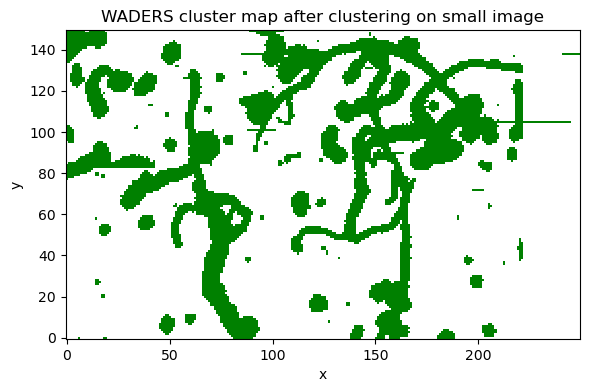

In [26]:
H, W = 150, 250
img = np.zeros((H, W), dtype=int)

for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = 1   # mark cluster pixels

# custom colormap: 0 -> white, 1 -> green
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(6, 4))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map after clustering on small image")
plt.tight_layout()
plt.show()

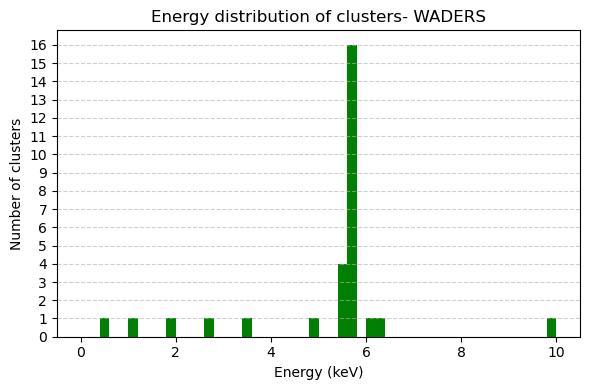

In [27]:
plt.figure(figsize=(6, 4))
plt.hist(df_expanded["Energy"], bins=50, color="green", range=(0, 10))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- WADERS")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

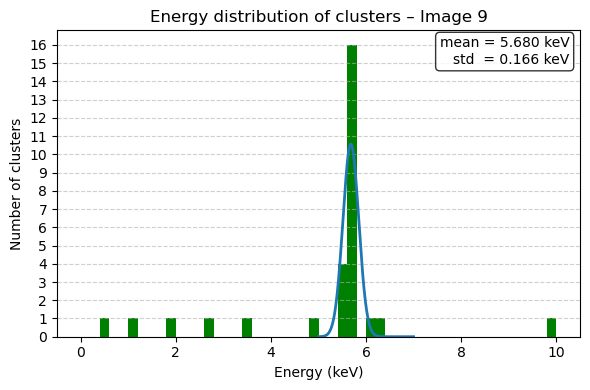

mean=5.680163, std=0.166160


In [28]:
# --- settings ---
bins = 50
hist_range = (0, 10)
fit_min, fit_max = 5.0, 7.0

# --- extract energy ---
data = df_expanded["Energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used ONLY for Gaussian fit ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]

# --- Gaussian MLE fit ---
mu, sigma = norm.fit(fit_data)

# --- plot histogram (unchanged from yours) ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(
    data, bins=bins, color="green", range=hist_range
)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – Image 9")

# --- overlay Gaussian ONLY over 2–7 keV ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 500)
pdf = norm.pdf(x, loc=mu, scale=sigma)

# scale PDF to histogram counts
y = pdf * len(fit_data) * bin_width
plt.plot(x, y, linewidth=2)

# --- annotate fit ---
plt.text(
    0.98, 0.98,
    f"mean = {mu:.3f} keV\n"
    f"std  = {sigma:.3f} keV",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- grid ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"mean={mu:.6f}, std={sigma:.6f}")